# Fuzzy logic as an answer for the management of micro grid power 
*Authors: Aaro Korpela & Matteo Mannarinno*
## 1. Introduction & Methodology
This notebook replicates the Fuzzy Logic Energy Management System (FL-EMS) proposed by Horillo-Quintero et al. (2024). 
The system uses Mamdani fuzzy inference to dynamically manage a multi-energy microgrid based on two inputs:
1. Gross Net Power ($P'_{NET}$)
2. Battery State of Charge (SOC)

Outputs generated using the centroid defuzzification method:
1. Electric Boiler Power ($P_{EB}$)
2. Electric Boiler Max Temperature ($T^{max}_{EB}$)
3. Heating Bus Temperature ($T_{bus}$)

In [1]:
# Install the fuzzy logic library if you haven't already
# !pip install scikit-fuzzy numpy matplotlib scipy

import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

In [2]:
# -----------------------------
# 1. Define fuzzy variables
# -----------------------------
# Net Power ranges from -23kW to +23kW
net_power = ctrl.Antecedent(np.arange(-23, 23.1, 0.1), 'net_power')
# SOC ranges from 0 to 1
soc = ctrl.Antecedent(np.arange(0, 1.0, 0.01), 'soc')

# --- OUTPUTS ---
bus_temp = ctrl.Consequent(np.arange(30, 35.1, 0.1), 'bus_temp')
boiler_power = ctrl.Consequent(np.arange(0, 9.21, 0.1), 'boiler_power')
hot_water = ctrl.Consequent(np.arange(48, 60.1, 0.1), 'hot_water')

# By default, scikit-fuzzy uses the 'centroid' method for defuzzification, 
# which perfectly matches your mathematical formulation section!

C:\Users\korpe\AppData\Roaming\Python\Python312\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


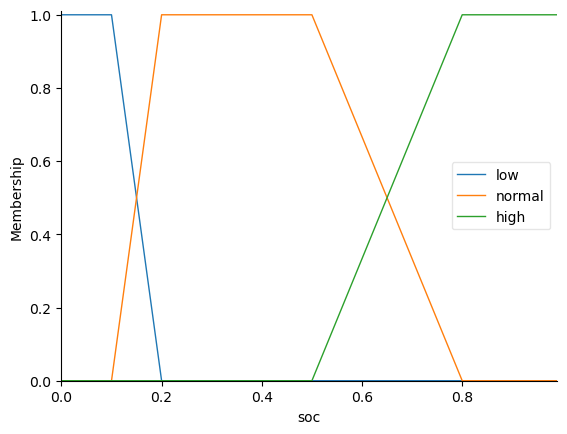

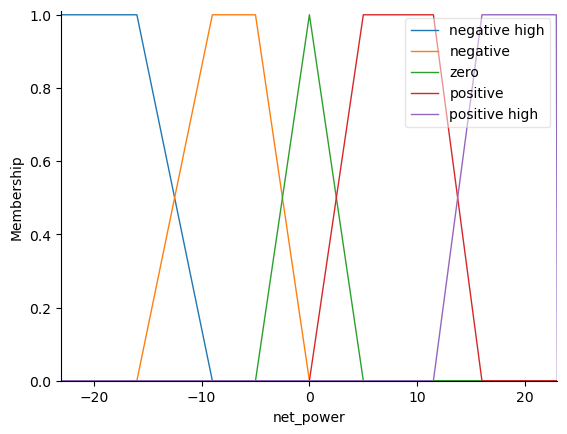

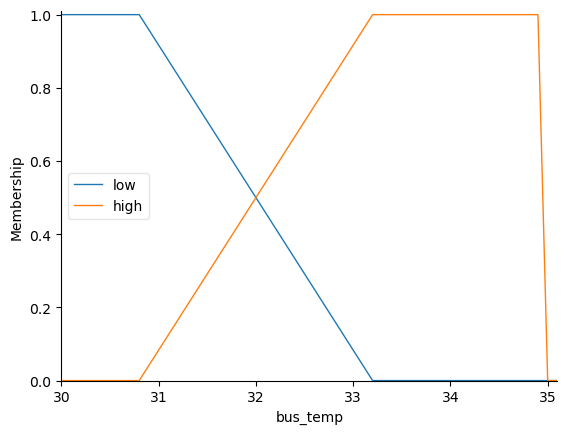

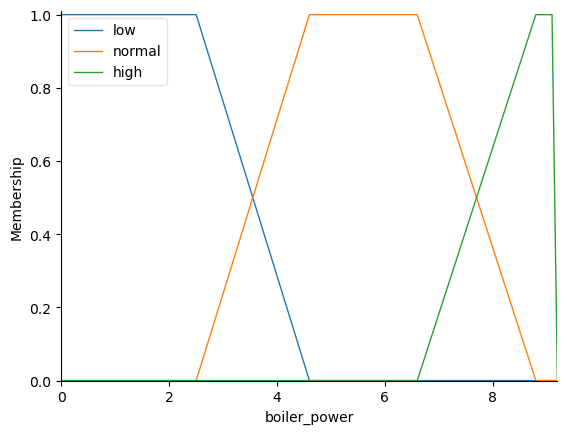

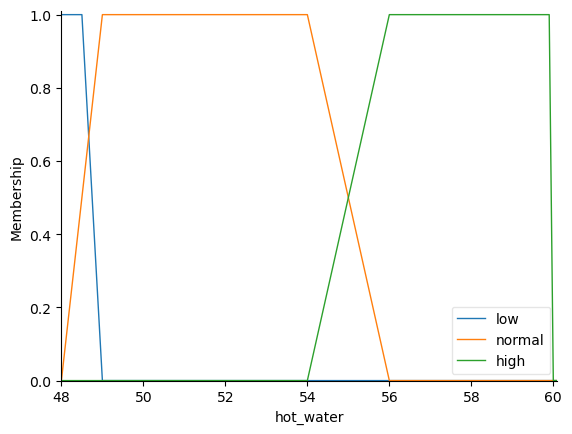

In [3]:
# -----------------------------
# 2. Membership functions
# -----------------------------
soc['low'] = fuzz.trapmf(soc.universe, [0, 0, 0.1, 0.2])
soc['normal'] = fuzz.trapmf(soc.universe, [0.1, 0.2, 0.5, 0.8])
soc['high'] = fuzz.trapmf(soc.universe, [0.5, 0.8, 1, 1])
soc.view()

net_power['negative high'] = fuzz.trapmf(net_power.universe, [-23, -23, -16, -9])
net_power['negative'] = fuzz.trapmf(net_power.universe, [-16,-9, -5, 0])
net_power['zero'] = fuzz.trimf(net_power.universe, [-5, 0, 5])
net_power['positive'] = fuzz.trapmf(net_power.universe, [0, 5, 11.5, 16])
net_power['positive high'] = fuzz.trapmf(net_power.universe, [11.5, 16, 23, 23])
net_power.view()

bus_temp['low'] = fuzz.trapmf(bus_temp.universe, [30, 30, 30.8, 33.2])
bus_temp['high'] = fuzz.trapmf(bus_temp.universe, [30.8, 33.2, 35, 35])
bus_temp.view()

boiler_power['low'] = fuzz.trapmf(boiler_power.universe, [0, 0, 2.5, 4.6])
boiler_power['normal'] = fuzz.trapmf(boiler_power.universe, [2.5, 4.6, 6.6, 8.8])
boiler_power['high'] = fuzz.trapmf(boiler_power.universe, [6.6, 8.8, 9.2, 9.2])
boiler_power.view() 

hot_water['low'] = fuzz.trapmf(hot_water.universe, [48, 48, 48.5, 49])
hot_water['normal'] = fuzz.trapmf(hot_water.universe, [48, 49, 54, 56])
hot_water['high'] = fuzz.trapmf(hot_water.universe, [54, 56, 60, 60])
hot_water.view()

In [ ]:
# -----------------------------
# 3. Fuzzy Rules & Control System
# -----------------------------

# We will define the full rule base consisting of 15 rules from the matrix.
# We also correct apparent logical typos where boiler power is normally reduced (Z/'low') 
# when net power is heavily negative (deficits), even if SOC is normal or high.
# P_EB (Z, N, H) -> boiler_power ('low', 'normal', 'high')
# T_EB (L, N, H) -> hot_water ('low', 'normal', 'high')
# T_bus (L, H) -> bus_temp ('low', 'high')

rules = []

# --- SOC: Low ---
rules.append(ctrl.Rule(soc['low'] & net_power['negative high'], [boiler_power['low'], hot_water['low'], bus_temp['high']]))
rules.append(ctrl.Rule(soc['low'] & net_power['negative'], [boiler_power['low'], hot_water['low'], bus_temp['high']]))
rules.append(ctrl.Rule(soc['low'] & net_power['zero'], [boiler_power['low'], hot_water['normal'], bus_temp['high']]))
rules.append(ctrl.Rule(soc['low'] & net_power['positive'], [boiler_power['normal'], hot_water['normal'], bus_temp['high']]))
rules.append(ctrl.Rule(soc['low'] & net_power['positive high'], [boiler_power['high'], hot_water['normal'], bus_temp['high']]))

# --- SOC: Normal ---
rules.append(ctrl.Rule(soc['normal'] & net_power['negative high'], [boiler_power['low'], hot_water['low'], bus_temp['high']]))
# Typo fixed here from the paper
rules.append(ctrl.Rule(soc['normal'] & net_power['negative'], [boiler_power['low'], hot_water['normal'], bus_temp['high']])) 
rules.append(ctrl.Rule(soc['normal'] & net_power['zero'], [boiler_power['normal'], hot_water['normal'], bus_temp['high']]))
rules.append(ctrl.Rule(soc['normal'] & net_power['positive'], [boiler_power['normal'], hot_water['normal'], bus_temp['high']]))
rules.append(ctrl.Rule(soc['normal'] & net_power['positive high'], [boiler_power['high'], hot_water['high'], bus_temp['low']]))

# --- SOC: High ---
# Typo fixed here from the paper
rules.append(ctrl.Rule(soc['high'] & net_power['negative high'], [boiler_power['low'], hot_water['normal'], bus_temp['high']]))
rules.append(ctrl.Rule(soc['high'] & net_power['negative'], [boiler_power['normal'], hot_water['high'], bus_temp['low']]))
rules.append(ctrl.Rule(soc['high'] & net_power['zero'], [boiler_power['high'], hot_water['high'], bus_temp['low']]))
rules.append(ctrl.Rule(soc['high'] & net_power['positive'], [boiler_power['high'], hot_water['high'], bus_temp['low']]))
rules.append(ctrl.Rule(soc['high'] & net_power['positive high'], [boiler_power['high'], hot_water['high'], bus_temp['low']]))

# Build the control system and simulation environment
ems_ctrl = ctrl.ControlSystem(rules)
ems_sim = ctrl.ControlSystemSimulation(ems_ctrl)


In [5]:
import pandas as pd
import numpy as np

# --- BATTERY CONSTRAINTS FUNCTION ---
def calculate_max_battery_power(soc, E_nom, delta_t, max_power_limit, mode='charge'):
    """
    Calculates the P_BESS_max based on the state of charge.
    SOC_min = 0.3, SOC_max = 0.9 as defined in the mathematical formulation.
    """
    soc_min = 0.3
    soc_max = 0.9
    
    if mode == 'discharge':
        limit = (E_nom / delta_t) * (soc - soc_min)
        return max(0, min(max_power_limit, limit))
    elif mode == 'charge':
        limit = (E_nom / delta_t) * (soc_max - soc)
        return max(0, min(max_power_limit, limit))
    return 0

# --- SIMULATION SETTINGS ---
start_hour = 7   # 07:00 AM
hours = 12
delta_t = 1  # hourly steps

# Physical Parameters
E_nom_battery = 15.0      # kWh
max_inverter_power = 5.0  # kW (Maximum power the battery inverter can handle)
tank_volume_l = 500       # 500 Liters
cp_water = 0.00116        # Specific heat of water in kWh/kg°C
thermal_capacity = tank_volume_l * cp_water  # kWh/°C

# Initial States
soc_current = 0.5         # Start at 50% SOC so it doesn't bottom out instantly
temp_water = 45.0         # Start at 45°C

# Synthetic 12-hour profiles starting from 07:00
# Increased PV profile moderately so there's more surplus energy to charge the battery
p_pv_profile = [1.0, 3.5, 6.5, 10.5, 14.5, 16.5, 15.5, 13.0, 9.0, 5.0, 2.0, 0.0]
p_load_profile = [1.5, 1.8, 2.2, 2.5, 2.5, 7.0, 7.5, 3.0, 2.8, 4.0, 4.5, 3.5]
p_heat_loss = 1.8  # kW (House heating consumption)

sim_results = []

for t in range(hours):
    current_time = (start_hour + t) % 24
    p_net_prime = p_pv_profile[t] - p_load_profile[t]
    
    # 1. Run Fuzzy Controller
    ems_sim.input['net_power'] = p_net_prime
    ems_sim.input['soc'] = soc_current
    
    # Using your friend's newer consequence naming structure ('boiler_power' instead of 'eb_power')
    try:
        ems_sim.compute()
        p_eb = ems_sim.output['boiler_power']
    except (ValueError, KeyError):
        # Fallback if no fuzzy rule was triggered for standard inputs
        p_eb = 0.0
    
    # 2. Battery SOC Update with Constraints
    p_to_battery = p_net_prime - p_eb
    
    # Check physical constraints before committing the energy to the battery
    if p_to_battery > 0:
        # Battery is trying to charge. Limit via state-of-charge and inverter limits.
        max_charge_power = calculate_max_battery_power(soc_current, E_nom_battery, delta_t, max_inverter_power, mode='charge')
        p_to_battery = min(p_to_battery, max_charge_power)
    elif p_to_battery < 0:
        # Battery is trying to discharge. Limit via state-of-charge and inverter limits.
        max_discharge_power = calculate_max_battery_power(soc_current, E_nom_battery, delta_t, max_inverter_power, mode='discharge')
        # Since p_to_battery is negative, we must clamp it from going below -max_discharge_power
        p_to_battery = max(p_to_battery, -max_discharge_power)
        
    soc_current += (p_to_battery / E_nom_battery) * delta_t
    soc_current = np.clip(soc_current, 0.2, 0.95)
    
    # 3. Thermal System Update (Temperature Model)
    # Energy balance: delta_temp = (Power_in - Power_out) * time / thermal_capacity
    p_thermal_net = (p_eb * 0.98) - p_heat_loss
    temp_water += (p_thermal_net * delta_t) / thermal_capacity
    temp_water = np.clip(temp_water, 35.0, 85.0) # Safety limits for hot water
    
    sim_results.append({
        'Time': f"{current_time:02d}:00",
        'Hour_Idx': t,
        'Solar': p_pv_profile[t],
        'Load': p_load_profile[t],
        'SOC': soc_current,
        'Boiler_Power': p_eb,
        'Water_Temp_C': temp_water
    })

df_sim = pd.DataFrame(sim_results)
print(df_sim[['Time', 'Solar', 'SOC', 'Boiler_Power', 'Water_Temp_C']])

     Time  Solar       SOC  Boiler_Power  Water_Temp_C
0   07:00    1.0  0.300000      5.361570     50.955757
1   08:00    3.5  0.300000      5.635099     57.373682
2   09:00    6.5  0.300000      5.631477     63.785489
3   10:00   10.5  0.458046      5.629317     70.193645
4   11:00   14.5  0.791379      5.679271     76.686206
5   12:00   16.5  0.891278      8.001512     85.000000
6   13:00   15.5  0.872198      8.286207     85.000000
7   14:00   13.0  0.900000      8.286207     85.000000
8   15:00    9.0  0.760920      8.286207     85.000000
9   16:00    5.0  0.427586      7.231658     85.000000
10  17:00    2.0  0.300000      4.131111     85.000000
11  18:00    0.0  0.300000      3.357521     85.000000


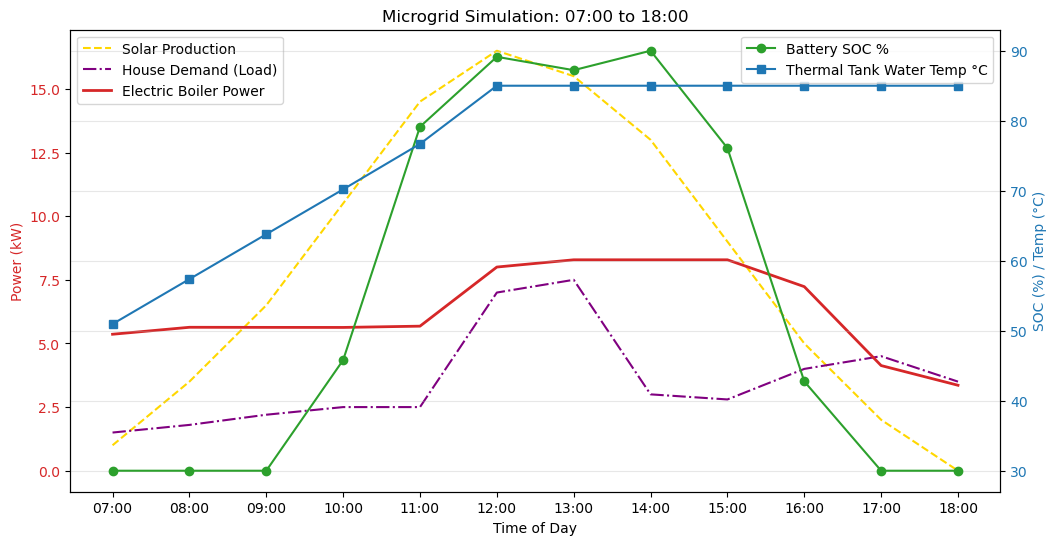

In [6]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Power Axis
ax1.set_xlabel('Time of Day')
ax1.set_ylabel('Power (kW)', color='tab:red')
ax1.plot(df_sim['Time'], df_sim['Solar'], label='Solar Production', color='gold', linestyle='--')
ax1.plot(df_sim['Time'], df_sim['Load'], label='House Demand (Load)', color='purple', linestyle='-.')
ax1.plot(df_sim['Time'], df_sim['Boiler_Power'], label='Electric Boiler Power', color='tab:red', linewidth=2)
ax1.tick_params(axis='y', labelcolor='tab:red')
ax1.legend(loc='upper left')

# Temperature and SOC Axis
ax2 = ax1.twinx()
ax2.set_ylabel('SOC (%) / Temp (°C)', color='tab:blue')
ax2.plot(df_sim['Time'], df_sim['SOC'] * 100, label='Battery SOC %', color='tab:green', marker='o')
ax2.plot(df_sim['Time'], df_sim['Water_Temp_C'], label='Thermal Tank Water Temp °C', color='tab:blue', marker='s')
ax2.tick_params(axis='y', labelcolor='tab:blue')
ax2.legend(loc='upper right')

plt.title(f'Microgrid Simulation: {df_sim["Time"].iloc[0]} to {df_sim["Time"].iloc[-1]}')
plt.grid(True, alpha=0.3)
plt.show()